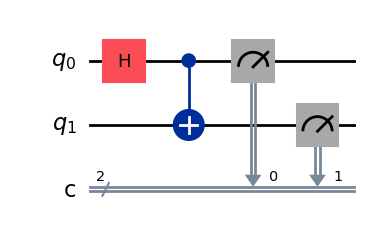

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Create entanglement (Bell state)
qc.h(0)
qc.cx(0, 1)

# Measure
qc.measure([0,1], [0,1])

# Draw circuit
qc.draw('mpl')

In [2]:
# Run on local simulator
sim = AerSimulator()
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
plt.show()

{'11': 539, '00': 461}


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="763035fde8a443df82fee152dec75845",
    overwrite=True
)

InvalidAccountError: "Invalid `channel` value. Expected one of ['ibm_cloud', 'ibm_quantum_platform'], got 'ibm_quantum'."

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Paste your token between the quotes
token = "UxjQEcSxJtTvxmdjmWrkfIpYqX-aaS_GwpoD33XTFUat"

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token=token,
    overwrite=True
)

print("Account saved successfully!")

InvalidAccountError: "Invalid `channel` value. Expected one of ['ibm_cloud', 'ibm_quantum_platform'], got 'ibm_quantum'."

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="UxjQEcSxJtTvxmdjmWrkfIpYqX-aaS_GwpoD33XTFUat",
    overwrite=True
)

InvalidAccountError: "Invalid `channel` value. Expected one of ['ibm_cloud', 'ibm_quantum_platform'], got 'ibm_quantum'."

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="6teOmDTRXP6d9SZ5WjXMvVFgJOhCXXGbCF4h_w7o5vIx",
    overwrite=True
)

print("Account saved successfully!")

Account saved successfully!


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# List all available backends
backends = service.backends()
for backend in backends:
    print(f"Name: {backend.name} | Qubits: {backend.num_qubits} | Status: {backend.status().operational}")

IBMInputValueError: 'No matching instances found for the following filters: .'

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Using the correct channel name for the standard IBM Quantum platform
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="UxjQEcSxJtTvxmdjmWrkfIpYqX-aaS_GwpoD33XTFUat", 
    overwrite=True
)

print("Account reset successfully with ibm_quantum_platform!")

Account reset successfully with ibm_quantum_platform!


In [9]:
service = QiskitRuntimeService()

# List only the real quantum computers (not simulators)
backends = service.backends(simulator=False, operational=True)
for backend in backends:
    print(f"Name: {backend.name} | Qubits: {backend.num_qubits}")

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="r3SRAun9Ht5Q9Fc53rTGc8heNNyc6fIeWcMMO-4js8BN",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/763035fde8a443df82fee152dec75845:975c13ff-9806-4bbc-a048-3bfeac419217::",
    overwrite=True
)

print("Account saved!")

Account saved!


In [11]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backends = service.backends(operational=True)
for backend in backends:
    print(f"Name: {backend.name} | Qubits: {backend.num_qubits} | Queue: {backend.status().pending_jobs}")

Name: ibm_marrakesh | Qubits: 156 | Queue: 0
Name: ibm_kingston | Qubits: 156 | Queue: 0
Name: ibm_fez | Qubits: 156 | Queue: 0


In [12]:
backend = service.least_busy(operational=True, simulator=False)
print(f"Using: {backend.name}")
print(f"Qubits available: {backend.num_qubits}")
print(f"Jobs ahead of you: {backend.status().pending_jobs}")

Using: ibm_marrakesh
Qubits available: 156
Jobs ahead of you: 0


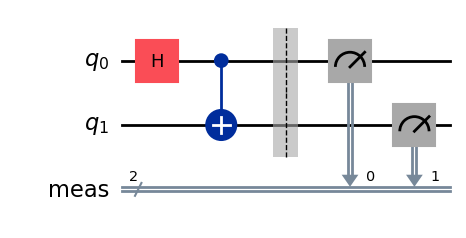

In [13]:
from qiskit import QuantumCircuit

# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Build Bell state (entanglement)
qc.h(0)          # Hadamard on qubit 0
qc.cx(0, 1)      # CNOT: entangle qubit 0 with qubit 1
qc.measure_all() # Measure both qubits

# Draw it
qc.draw('mpl')

Circuit optimized for hardware!


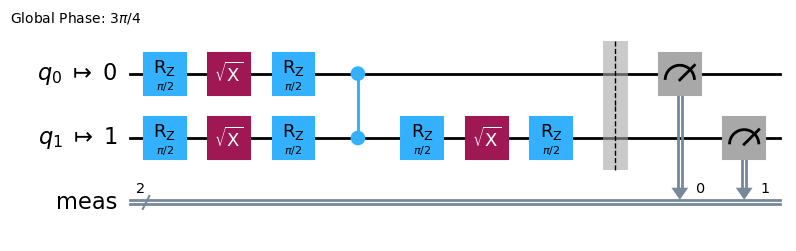

In [14]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

print("Circuit optimized for hardware!")
isa_circuit.draw('mpl', idle_wires=False)

In [15]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=1000)

print(f"Job ID: {job.job_id()}")
print(f"Status: {job.status()}")
print("Job sent to real quantum computer!")

Job ID: d8irtac2upec739mkc7g
Status: QUEUED
Job sent to real quantum computer!


In [16]:
print(f"Status: {job.status()}")

Status: DONE


Results from REAL quantum computer:
{'00': 500, '11': 485, '10': 10, '01': 5}


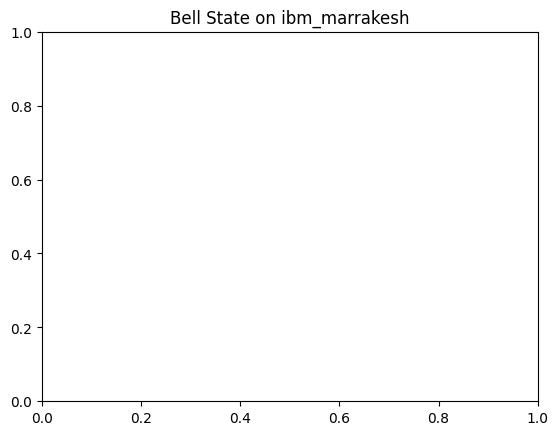

In [17]:
result = job.result()
counts = result[0].data.meas.get_counts()

print("Results from REAL quantum computer:")
print(counts)

# Plot
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts)
plt.title(f"Bell State on {backend.name}")
plt.show()

In [18]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
perfect_result = sim.run(qc, shots=1000).result()
perfect_counts = perfect_result.get_counts()

print("Perfect (Simulator):", perfect_counts)
print("Real Hardware:      ", counts)

Perfect (Simulator): {'00': 505, '11': 495}
Real Hardware:       {'00': 500, '11': 485, '10': 10, '01': 5}


In [19]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create 1 qubit
qc = QuantumCircuit(1, 1)

# Put it in superposition — 50/50 chance of 0 or 1
qc.h(0)

# Measure — collapse to either 0 or 1, truly randomly
qc.measure(0, 0)

# Draw it
print(qc.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


In [20]:
sim = AerSimulator()
result = sim.run(qc, shots=1).result()
bit = list(result.get_counts().keys())[0]
print(f"Your random bit: {bit}")

Your random bit: 0


In [21]:
import string

def quantum_password(length=12):
    """Generate a truly random password using quantum mechanics."""
    
    # All possible characters
    chars = string.ascii_letters + string.digits + "!@#$%^&*"
    char_count = len(chars)  # ~70 characters
    
    # We need enough bits to index into chars
    # 7 bits = 128 possibilities (more than enough)
    bits_needed = 7
    
    password = ""
    
    while len(password) < length:
        # Generate random number
        random_num, _ = quantum_random_number(bits_needed)
        
        # Use it to pick a character (modulo to fit range)
        if random_num < char_count:
            password += chars[random_num]
    
    return password

# Generate 5 quantum-secure passwords
print("🔐 Quantum-Generated Passwords:\n")
for i in range(5):
    pw = quantum_password(16)
    print(f"Password {i+1}: {pw}")

🔐 Quantum-Generated Passwords:



NameError: name 'quantum_random_number' is not defined

In [22]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_random_number(num_bits=8):
    """Generate a truly random number using quantum superposition."""
    
    # Create circuit with num_bits qubits
    qc = QuantumCircuit(num_bits, num_bits)
    
    # Put every qubit into superposition
    for i in range(num_bits):
        qc.h(i)
    
    # Measure all qubits
    qc.measure(range(num_bits), range(num_bits))
    
    # Run on simulator (single shot = one random number)
    sim = AerSimulator()
    result = sim.run(qc, shots=1).result()
    
    # Get the binary string
    binary_string = list(result.get_counts().keys())[0]
    
    # Convert to integer
    return int(binary_string, 2), binary_string

# Generate 10 random numbers
print("=== Quantum Random Numbers (0-255) ===\n")
for i in range(10):
    number, binary = quantum_random_number(8)
    print(f"Random #{i+1}: {number:3d}  (binary: {binary})")

=== Quantum Random Numbers (0-255) ===

Random #1: 176  (binary: 10110000)
Random #2: 182  (binary: 10110110)
Random #3: 250  (binary: 11111010)
Random #4: 151  (binary: 10010111)
Random #5:  23  (binary: 00010111)
Random #6:  65  (binary: 01000001)
Random #7:  72  (binary: 01001000)
Random #8: 106  (binary: 01101010)
Random #9: 126  (binary: 01111110)
Random #10: 143  (binary: 10001111)


In [23]:
def quantum_dice():
    """Roll a quantum die (1-6)."""
    
    # 3 qubits give us 0-7, we'll reject 0, 6, 7 and reroll
    while True:
        number, _ = quantum_random_number(3)
        if 1 <= number <= 6:
            return number

# Roll the quantum dice 10 times
print("🎲 Rolling quantum dice...\n")
for i in range(10):
    roll = quantum_dice()
    print(f"Roll {i+1}: {roll}")

🎲 Rolling quantum dice...

Roll 1: 2
Roll 2: 4
Roll 3: 4
Roll 4: 4
Roll 5: 4
Roll 6: 3
Roll 7: 4
Roll 8: 2
Roll 9: 3
Roll 10: 6


Out of 1000 random bits:
  Zeros: 480
  Ones:  520
  Ratio: 0.480 : 0.520


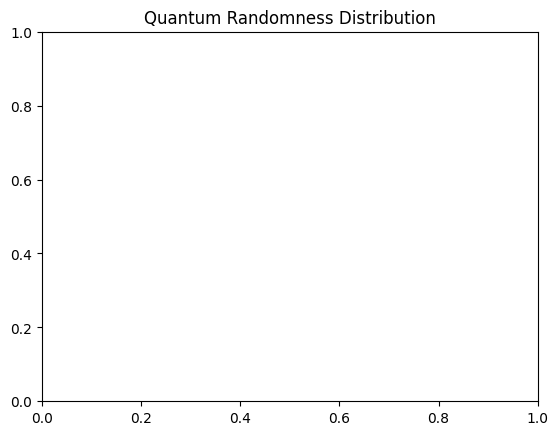

In [24]:
import matplotlib.pyplot as plt

# Generate 1000 random single bits at once
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

sim = AerSimulator()
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

print(f"Out of 1000 random bits:")
print(f"  Zeros: {counts.get('0', 0)}")
print(f"  Ones:  {counts.get('1', 0)}")
print(f"  Ratio: {counts.get('0', 0) / 1000:.3f} : {counts.get('1', 0) / 1000:.3f}")

# Plot
from qiskit.visualization import plot_histogram
plot_histogram(counts)
plt.title("Quantum Randomness Distribution")
plt.show()

In [25]:
import string

def quantum_password(length=12):
    """Generate a truly random password using quantum mechanics."""
    
    # All possible characters
    chars = string.ascii_letters + string.digits + "!@#$%^&*"
    char_count = len(chars)  # ~70 characters
    
    # We need enough bits to index into chars
    # 7 bits = 128 possibilities (more than enough)
    bits_needed = 7
    
    password = ""
    
    while len(password) < length:
        # Generate random number
        random_num, _ = quantum_random_number(bits_needed)
        
        # Use it to pick a character (modulo to fit range)
        if random_num < char_count:
            password += chars[random_num]
    
    return password

# Generate 5 quantum-secure passwords
print("🔐 Quantum-Generated Passwords:\n")
for i in range(5):
    pw = quantum_password(16)
    print(f"Password {i+1}: {pw}")

🔐 Quantum-Generated Passwords:

Password 1: ^67!$8Vdncs8v7wi
Password 2: pU3G#R0LlgyV@gAY
Password 3: pKx!&QcdKTwrhdbS
Password 4: 7YFa8YTPETJ$gh0y
Password 5: I&rKp2b3r1FnB32k


In [26]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Build the circuit
qc = QuantumCircuit(8, 8)
for i in range(8):
    qc.h(i)
qc.measure(range(8), range(8))

# Optimize for real hardware
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Send to real quantum computer
sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=100)
print(f"Job ID: {job.job_id()}")
print(f"Status: {job.status()}")

Job ID: d8is0p66983c73dsh1j0
Status: QUEUED


In [27]:
print(f"Status: {job.status()}")

Status: DONE


In [28]:
result = job.result()
counts = result[0].data.c.get_counts()

print("100 truly random numbers from REAL quantum hardware:\n")
numbers = []
for bitstring, count in counts.items():
    for _ in range(count):
        numbers.append(int(bitstring, 2))

# Show first 20
for i, num in enumerate(numbers[:20]):
    print(f"#{i+1}: {num}")

# Stats
print(f"\nTotal numbers generated: {len(numbers)}")
print(f"Min: {min(numbers)}")
print(f"Max: {max(numbers)}")
print(f"Average: {sum(numbers)/len(numbers):.2f} (expected ~127.5)")

100 truly random numbers from REAL quantum hardware:

#1: 250
#2: 79
#3: 205
#4: 49
#5: 217
#6: 217
#7: 127
#8: 127
#9: 31
#10: 31
#11: 136
#12: 45
#13: 45
#14: 45
#15: 243
#16: 243
#17: 58
#18: 4
#19: 4
#20: 229

Total numbers generated: 100
Min: 1
Max: 250
Average: 115.94 (expected ~127.5)


In [29]:
def quantum_music_notes(num_notes=8):
    """Generate random musical notes using quantum mechanics."""
    
    notes = ['C', 'D', 'E', 'F', 'G', 'A', 'B', 'C']  # 8 notes = 3 qubits
    melody = []
    
    qc = QuantumCircuit(3, 3)
    qc.h([0, 1, 2])
    qc.measure([0, 1, 2], [0, 1, 2])
    
    sim = AerSimulator()
    result = sim.run(qc, shots=num_notes, memory=True).result()
    measurements = result.get_memory()
    
    for m in measurements:
        index = int(m, 2)
        melody.append(notes[index])
    
    return melody

print("🎵 Your Quantum Melody:")
print(' '.join(quantum_music_notes(16)))

🎵 Your Quantum Melody:
C E D G F C E C F B B G D E C B


In [30]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# Create a qubit in interesting state
qc = QuantumCircuit(1)
qc.h(0)
qc.t(0)
qc.h(0)

# Get the state vector
state = Statevector(qc)

# Plot on Bloch sphere
plot_bloch_multivector(state)
plt.show()

print("This is your qubit's state visualized in 3D!")

This is your qubit's state visualized in 3D!


In [31]:
%matplotlib inline

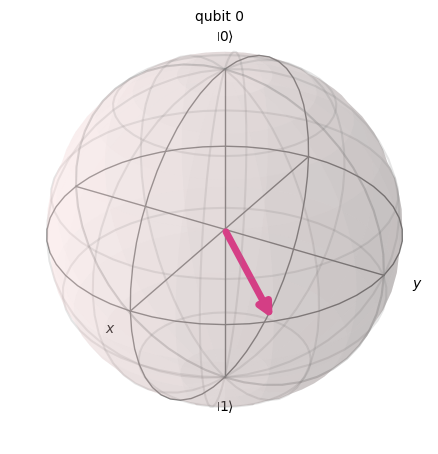

In [32]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# Create a qubit in an interesting state
qc = QuantumCircuit(1)
qc.h(0)      # Superposition
qc.t(0)      # Phase rotation

# Get the state vector
state = Statevector(qc)

# Plot on Bloch sphere
plot_bloch_multivector(state)
plt.show()

In [33]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import string

def quantum_random_number(num_bits):
    """Generate a truly random number using quantum superposition."""
    qc = QuantumCircuit(num_bits, num_bits)
    qc.h(range(num_bits))
    qc.measure(range(num_bits), range(num_bits))
    
    sim = AerSimulator()
    result = sim.run(qc, shots=1).result()
    binary = list(result.get_counts().keys())[0]
    return int(binary, 2)


def quantum_password(length=12):
    """Generate a secure 12-character password using quantum randomness."""
    
    chars = string.ascii_letters + string.digits + "!@#$%^&*"
    char_count = len(chars)
    bits_needed = char_count.bit_length()
    
    password = ""
    while len(password) < length:
        random_num = quantum_random_number(bits_needed)
        if random_num < char_count:
            password += chars[random_num]
    
    return password


# Generate 5 quantum 12-character passwords
print("🔐 Your Quantum 12-Character Passwords:\n")
print("=" * 30)
for i in range(5):
    pw = quantum_password(12)
    print(f"  {i+1}. {pw}")
print("=" * 30)

🔐 Your Quantum 12-Character Passwords:

  1. Px%Z4l#tTY^P
  2. m!IBxbFLv6c8
  3. PB$CQcThfbn*
  4. 0iQB*z528ovz
  5. Ge81&SzE84I*


In [34]:
%matplotlib inline
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_city
import matplotlib.pyplot as plt
import numpy as np

TypeError: plot_bloch_multivector() got an unexpected keyword argument 'ax'

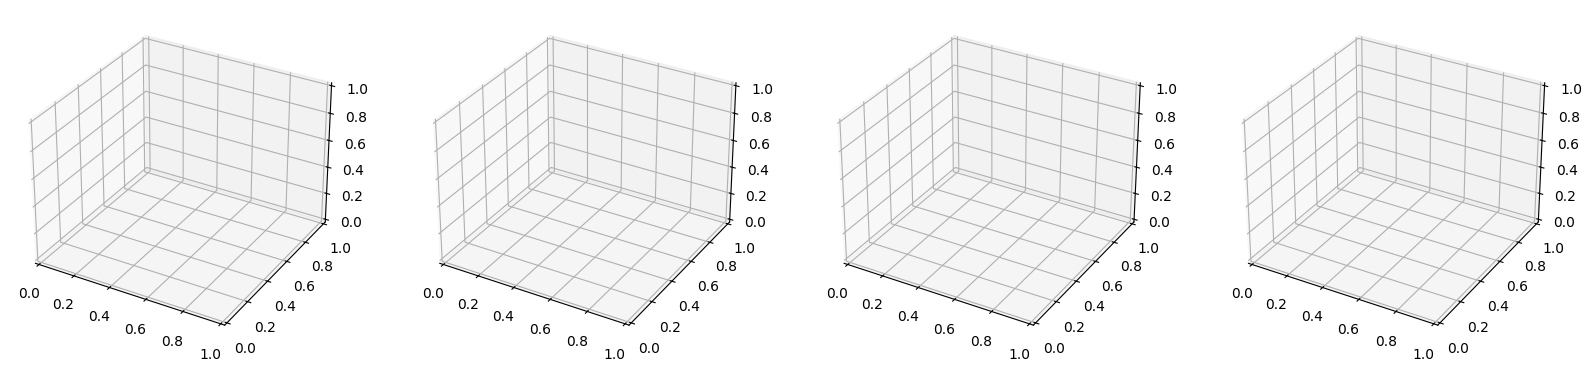

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})

# State |0⟩
qc1 = QuantumCircuit(1)
state1 = Statevector(qc1)

# State |1⟩
qc2 = QuantumCircuit(1)
qc2.x(0)
state2 = Statevector(qc2)

# State |+⟩ (superposition)
qc3 = QuantumCircuit(1)
qc3.h(0)
state3 = Statevector(qc3)

# State |+i⟩ (complex superposition)
qc4 = QuantumCircuit(1)
qc4.h(0)
qc4.s(0)
state4 = Statevector(qc4)

states = [state1, state2, state3, state4]
titles = ['|0⟩\n(Definite zero)', '|1⟩\n(Definite one)', 
          '|+⟩ = (|0⟩+|1⟩)/√2\n(Superposition!)', 
          '|+i⟩\n(Complex superposition)']

for ax, state, title in zip(axes, states, titles):
    plot_bloch_multivector(state, ax=ax)
    ax.set_title(title, fontsize=11)

plt.suptitle("🌐 The Bloch Sphere — Where Qubits Live", fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Notice:")
print("   |0⟩ → arrow points UP (north pole)")
print("   |1⟩ → arrow points DOWN (south pole)")
print("   |+⟩ → arrow points along EQUATOR (true superposition!)")
print("   The equator is where superposition lives")


  |0⟩ - Definite zero


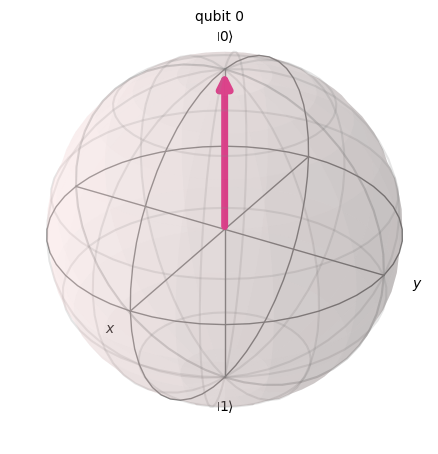


  |1⟩ - Definite one


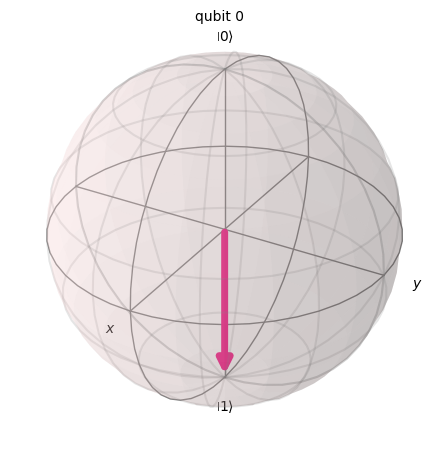


  |+⟩ - Equal Superposition!


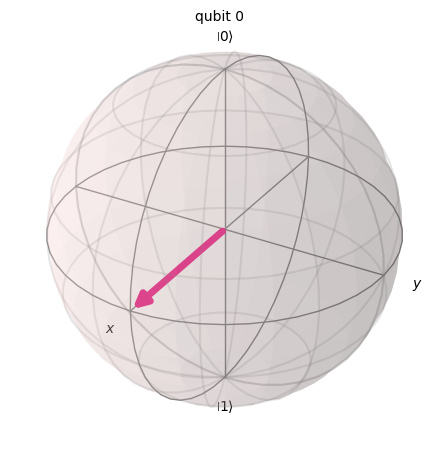


  |+i⟩ - Complex Superposition


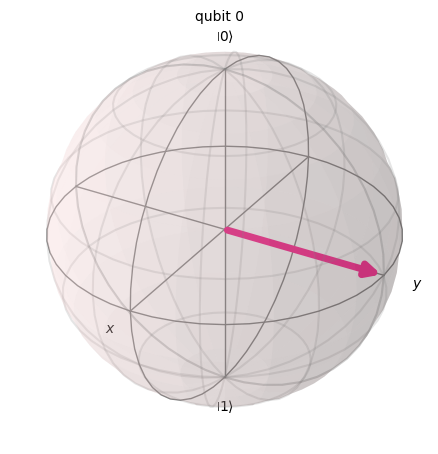


💡 Notice:
   |0⟩ → arrow points UP (north pole)
   |1⟩ → arrow points DOWN (south pole)
   |+⟩ → arrow points along EQUATOR (true superposition!)
   |+i⟩ → arrow on equator but rotated 90° around

   The equator is where superposition lives 🌐


In [36]:
%matplotlib inline
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

# State |0⟩
qc1 = QuantumCircuit(1)
state1 = Statevector(qc1)

# State |1⟩
qc2 = QuantumCircuit(1)
qc2.x(0)
state2 = Statevector(qc2)

# State |+⟩ (superposition)
qc3 = QuantumCircuit(1)
qc3.h(0)
state3 = Statevector(qc3)

# State |+i⟩ (complex superposition)
qc4 = QuantumCircuit(1)
qc4.h(0)
qc4.s(0)
state4 = Statevector(qc4)

states = [state1, state2, state3, state4]
titles = ['|0⟩ - Definite zero', 
          '|1⟩ - Definite one', 
          '|+⟩ - Equal Superposition!', 
          '|+i⟩ - Complex Superposition']

# Plot each one separately
for state, title in zip(states, titles):
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    fig = plot_bloch_multivector(state)
    plt.show()

print("\n💡 Notice:")
print("   |0⟩ → arrow points UP (north pole)")
print("   |1⟩ → arrow points DOWN (south pole)")
print("   |+⟩ → arrow points along EQUATOR (true superposition!)")
print("   |+i⟩ → arrow on equator but rotated 90° around")
print("\n   The equator is where superposition lives 🌐")

C:\Users\harve\AppData\Local\Temp\ipykernel_19912\4153352569.py:24: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


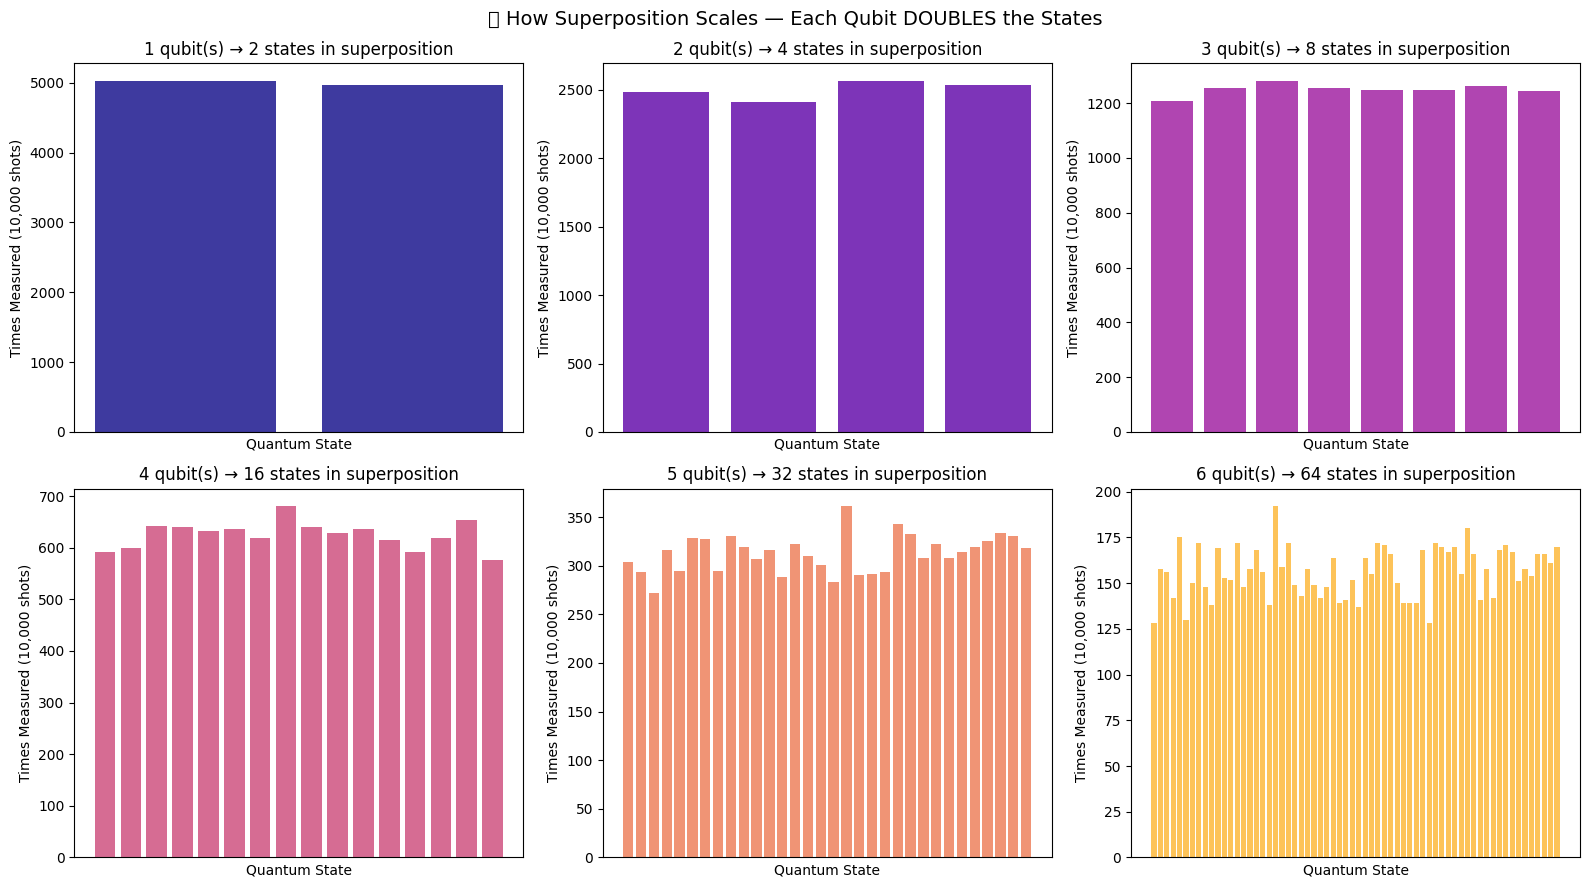


🤯 If we kept going:
   10 qubits = 1,024 states simultaneously
   20 qubits = ~1 million states
   50 qubits = ~1 quadrillion states
   300 qubits = more states than atoms in the universe!


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("🌌 How Superposition Scales — Each Qubit DOUBLES the States", fontsize=14)

for idx, num_qubits in enumerate([1, 2, 3, 4, 5, 6]):
    qc = QuantumCircuit(num_qubits, num_qubits)
    qc.h(range(num_qubits))
    qc.measure(range(num_qubits), range(num_qubits))
    
    sim = AerSimulator()
    result = sim.run(qc, shots=10000).result()
    counts = result.get_counts()
    
    ax = axes[idx // 3, idx % 3]
    
    sorted_counts = dict(sorted(counts.items()))
    ax.bar(range(len(sorted_counts)), list(sorted_counts.values()),
           color=plt.cm.plasma(idx / 6), alpha=0.8)
    
    ax.set_title(f"{num_qubits} qubit(s) → {2**num_qubits} states in superposition")
    ax.set_xlabel("Quantum State")
    ax.set_ylabel("Times Measured (10,000 shots)")
    ax.set_xticks([])

plt.tight_layout()
plt.show()

print("\n🤯 If we kept going:")
print("   10 qubits = 1,024 states simultaneously")
print("   20 qubits = ~1 million states")
print("   50 qubits = ~1 quadrillion states")
print("   300 qubits = more states than atoms in the universe!")

C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


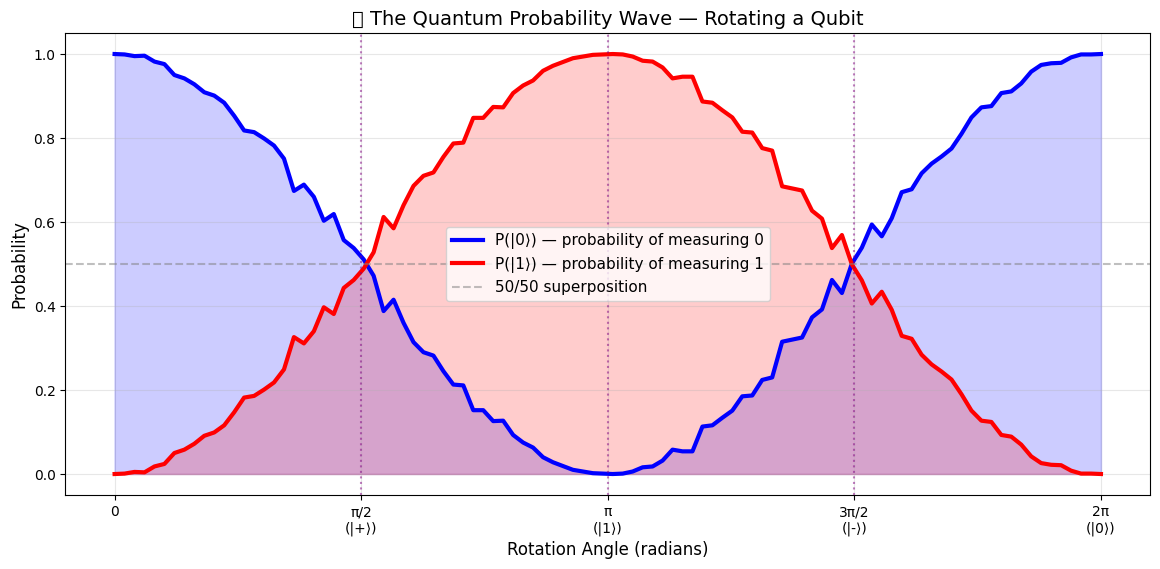


💡 What you're seeing:
   At 0° → 100% |0⟩ (no superposition)
   At 90° → 50/50 superposition (maximum uncertainty)
   At 180° → 100% |1⟩ (flipped)
   The smooth curve = probability amplitudes


In [38]:
angles = np.linspace(0, 2*np.pi, 100)
prob_0 = []
prob_1 = []

sim = AerSimulator()

for angle in angles:
    qc = QuantumCircuit(1, 1)
    qc.ry(angle, 0)  # Rotate the qubit around Y axis
    qc.measure(0, 0)
    
    result = sim.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    prob_0.append(counts.get('0', 0) / 1000)
    prob_1.append(counts.get('1', 0) / 1000)

plt.figure(figsize=(14, 6))
plt.plot(angles, prob_0, 'b-', label='P(|0⟩) — probability of measuring 0', linewidth=3)
plt.plot(angles, prob_1, 'r-', label='P(|1⟩) — probability of measuring 1', linewidth=3)
plt.fill_between(angles, prob_0, alpha=0.2, color='blue')
plt.fill_between(angles, prob_1, alpha=0.2, color='red')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50/50 superposition')
plt.axvline(x=np.pi/2, color='purple', linestyle=':', alpha=0.5)
plt.axvline(x=np.pi, color='purple', linestyle=':', alpha=0.5)
plt.axvline(x=3*np.pi/2, color='purple', linestyle=':', alpha=0.5)

plt.xlabel('Rotation Angle (radians)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('🌊 The Quantum Probability Wave — Rotating a Qubit', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2\n(|+⟩)', 'π\n(|1⟩)', '3π/2\n(|-⟩)', '2π\n(|0⟩)'])
plt.show()

print("\n💡 What you're seeing:")
print("   At 0° → 100% |0⟩ (no superposition)")
print("   At 90° → 50/50 superposition (maximum uncertainty)")
print("   At 180° → 100% |1⟩ (flipped)")
print("   The smooth curve = probability amplitudes")

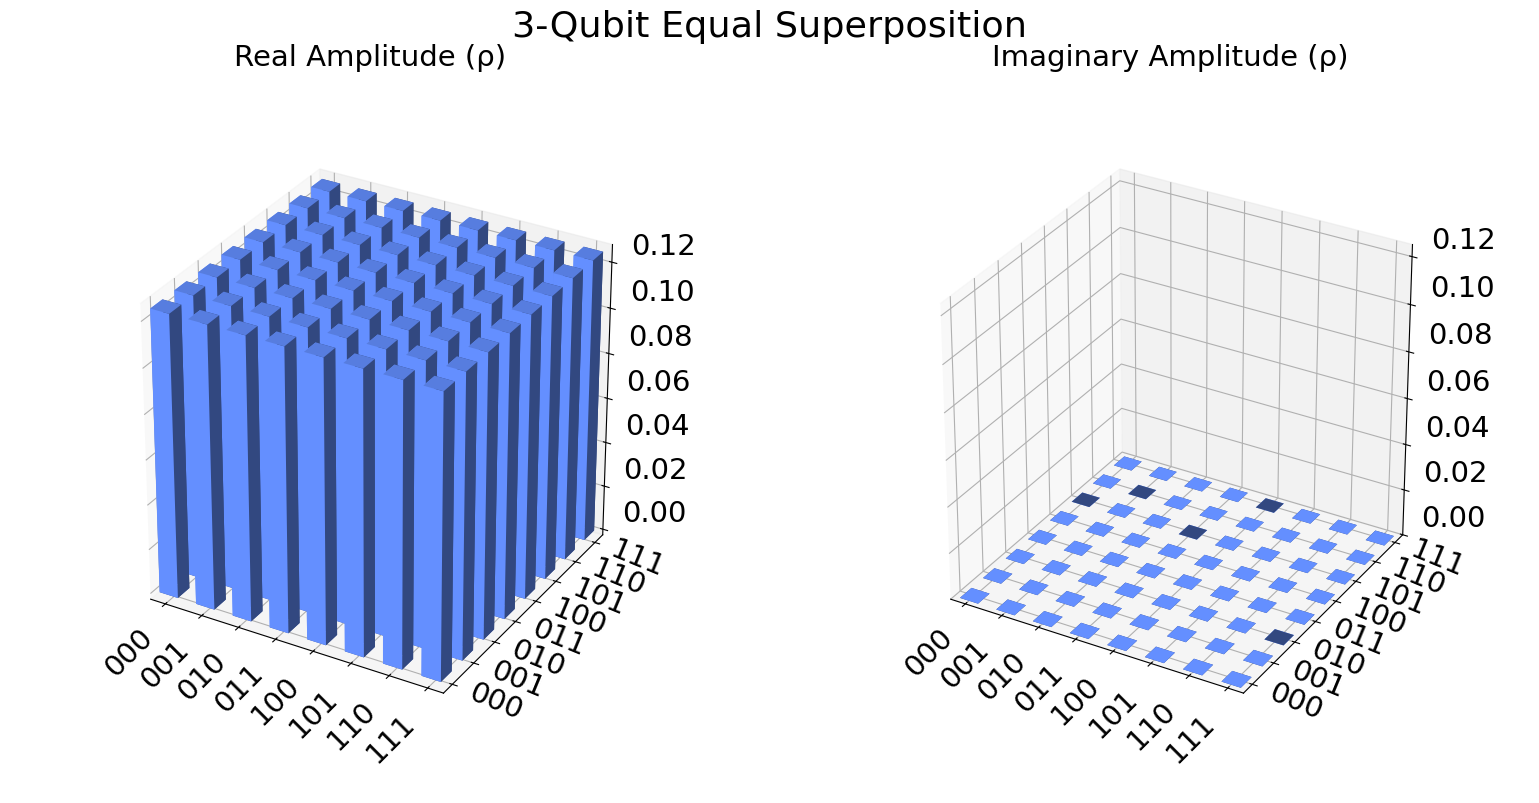


🏛️ What you're seeing:
   8 buildings = 8 possible states (2³ = 8)
   Equal heights = equal probability of each
   This is what 3 qubits in superposition look like


In [39]:
# Create a 3-qubit superposition
qc = QuantumCircuit(3)
qc.h(0)
qc.h(1)
qc.h(2)

state = Statevector(qc)

# Visualize as a "city" where building height = amplitude
fig = plot_state_city(state, title="3-Qubit Equal Superposition")
plt.show()

print("\n🏛️ What you're seeing:")
print("   8 buildings = 8 possible states (2³ = 8)")
print("   Equal heights = equal probability of each")
print("   This is what 3 qubits in superposition look like")

C:\Users\harve\AppData\Local\Temp\ipykernel_19912\3160017229.py:27: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


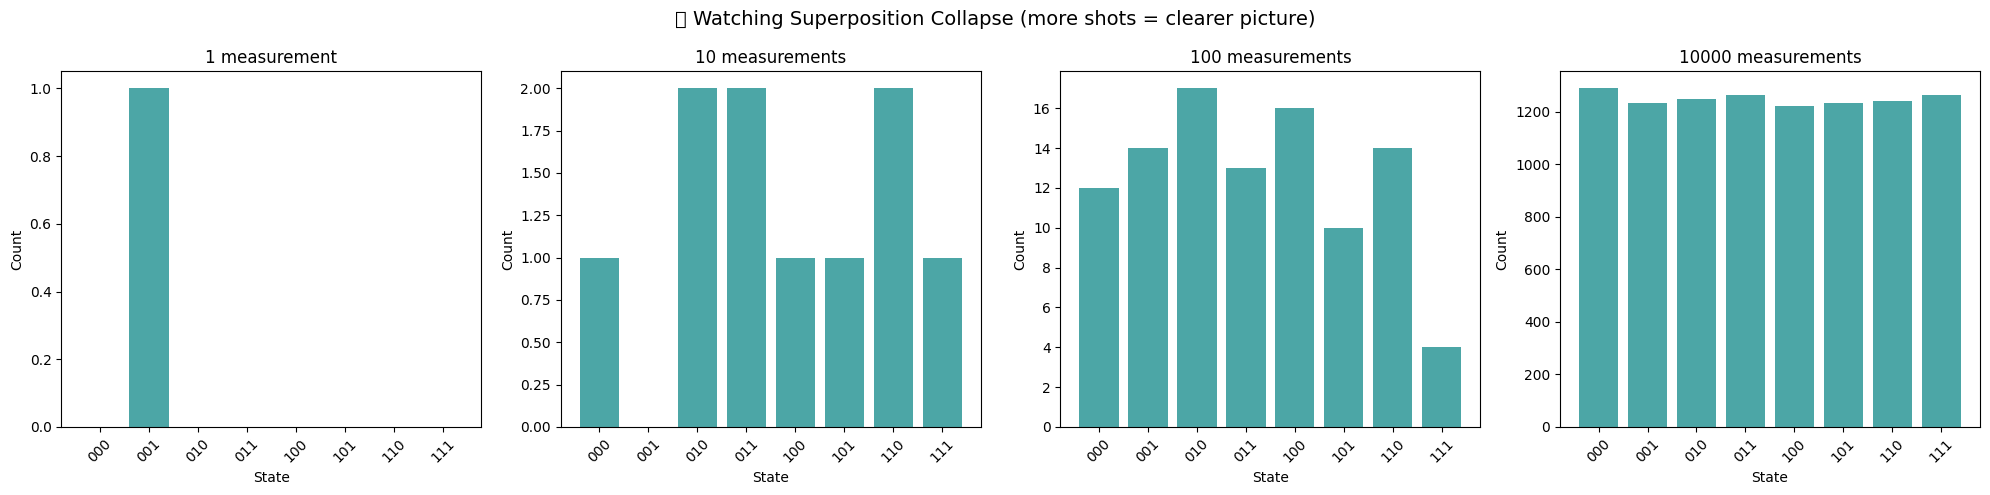


💡 What you're seeing:
   With 1 shot → looks random, you see ONE state
   With 10 shots → still noisy
   With 100 shots → starting to look uniform
   With 10,000 shots → clearly equal superposition

   Each measurement collapses the superposition!
   The PATTERN reveals the underlying probabilities.


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("🔬 Watching Superposition Collapse (more shots = clearer picture)", fontsize=14)

shot_counts = [1, 10, 100, 10000]

for ax, shots in zip(axes, shot_counts):
    qc = QuantumCircuit(3, 3)
    qc.h([0, 1, 2])
    qc.measure([0, 1, 2], [0, 1, 2])
    
    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    # Make sure all 8 states show even if not measured
    all_states = [format(i, '03b') for i in range(8)]
    full_counts = {s: counts.get(s, 0) for s in all_states}
    
    ax.bar(full_counts.keys(), full_counts.values(), color='teal', alpha=0.7)
    ax.set_title(f"{shots} measurement{'s' if shots > 1 else ''}")
    ax.set_xlabel("State")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 What you're seeing:")
print("   With 1 shot → looks random, you see ONE state")
print("   With 10 shots → still noisy")
print("   With 100 shots → starting to look uniform")
print("   With 10,000 shots → clearly equal superposition")
print("\n   Each measurement collapses the superposition!")
print("   The PATTERN reveals the underlying probabilities.")

TypeError: plot_bloch_multivector() got an unexpected keyword argument 'ax'

C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


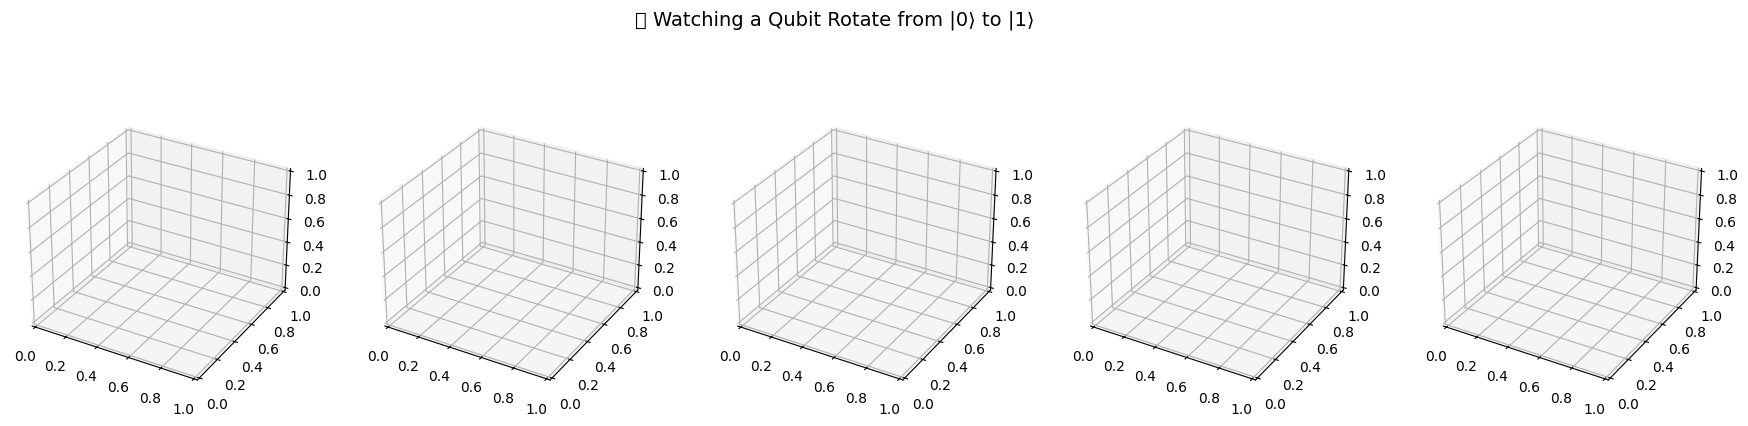

In [41]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), subplot_kw={'projection': '3d'})
fig.suptitle("🎬 Watching a Qubit Rotate from |0⟩ to |1⟩", fontsize=14)

angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
labels = ['0°\n|0⟩', '45°\n(slight tilt)', '90°\n|+⟩ Superposition!', 
          '135°\n(other side)', '180°\n|1⟩']

for ax, angle, label in zip(axes, angles, labels):
    qc = QuantumCircuit(1)
    qc.ry(angle, 0)
    state = Statevector(qc)
    
    plot_bloch_multivector(state, ax=ax)
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 What you're seeing:")
print("   The arrow continuously rotates from north pole to south pole")
print("   At 90° it's on the equator — TRUE superposition")
print("   This continuous rotation is what makes qubits powerful")
print("   Classical bits can ONLY be at the poles!")

AttributeError: 'NoneType' object has no attribute 'get_extents'

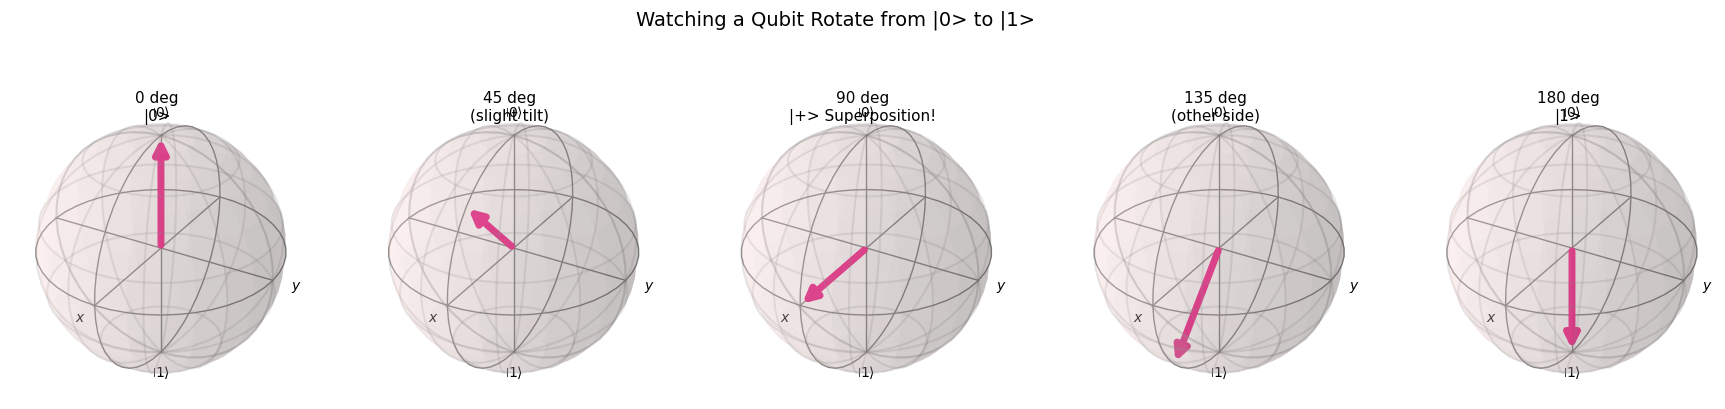

In [42]:
%matplotlib inline
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(22, 5), subplot_kw={'projection': '3d'})
fig.suptitle("Watching a Qubit Rotate from |0> to |1>", fontsize=14)

angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
labels = ['0 deg\n|0>', 
          '45 deg\n(slight tilt)', 
          '90 deg\n|+> Superposition!', 
          '135 deg\n(other side)', 
          '180 deg\n|1>']

for ax, angle, label in zip(axes, angles, labels):
    # Calculate Bloch vector directly from rotation angle
    # RY rotation: x = sin(angle), y = 0, z = cos(angle)
    x = np.sin(angle)
    y = 0
    z = np.cos(angle)
    
    plot_bloch_vector([x, y, z], ax=ax)
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

print("\nWhat you're seeing:")
print("   The arrow rotates continuously from north pole to south pole")
print("   At 90 degrees it's on the equator - TRUE superposition")
print("   This continuous rotation is what makes qubits powerful")
print("   Classical bits can ONLY be at the poles!")

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI units)
hbar = 1.054571817e-34   # Reduced Planck constant (J·s)
m_e = 9.1093837015e-31   # Electron mass (kg)
eV = 1.602176634e-19     # 1 eV in Joules
angstrom = 1e-10         # 1 Angstrom in meters


def tunneling_probability(E_eV, V0_eV, L_angstrom, mass=m_e):
    """
    Calculate quantum tunneling probability through a rectangular barrier.
    
    Parameters:
    -----------
    E_eV : float
        Energy of the particle (electron volts)
    V0_eV : float
        Height of the barrier (electron volts)
    L_angstrom : float
        Width of the barrier (Angstroms)
    mass : float
        Particle mass (kg) - defaults to electron mass
        
    Returns:
    --------
    T : float
        Tunneling probability (0 to 1)
    """
    
    # Convert to SI units
    E = E_eV * eV
    V0 = V0_eV * eV
    L = L_angstrom * angstrom
    
    if E < V0:
        # CLASSICAL TUNNELING (E < V0)
        # Particle "shouldn't" pass but quantum mechanics says it can
        kappa = np.sqrt(2 * mass * (V0 - E)) / hbar
        
        # Tunneling formula
        sinh_term = np.sinh(kappa * L)
        denominator = 1 + (V0**2 * sinh_term**2) / (4 * E * (V0 - E))
        T = 1 / denominator
        
    elif E > V0:
        # OVER-BARRIER (E > V0)
        # Classically passes, but quantum reflection happens
        k = np.sqrt(2 * mass * (E - V0)) / hbar
        
        sin_term = np.sin(k * L)
        denominator = 1 + (V0**2 * sin_term**2) / (4 * E * (E - V0))
        T = 1 / denominator
        
    else:
        # E exactly equals V0 (rare edge case)
        T = 1 / (1 + (mass * V0 * L**2) / (2 * hbar**2))
    
    return T


# ===========================================
# EXAMPLE 1: Single calculation
# ===========================================

print("=" * 60)
print("EXAMPLE 1: Electron Tunneling Through a Barrier")
print("=" 

_IncompleteInputError: incomplete input (2685483385.py, line 69)

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h_bar = 1.0545718e-34      # Reduced Planck constant (J·s)
m_e = 9.10938356e-31       # Electron mass (kg)
eV = 1.602176634e-19       # 1 electron volt in Joules


def tunneling_probability(E_eV, V0_eV, L_nm):
    """
    Calculate quantum tunneling probability for an electron.
    
    Parameters:
        E_eV: Electron energy (eV)
        V0_eV: Barrier height (eV)
        L_nm: Barrier width (nanometers)
    
    Returns:
        T: Tunneling probability (0 to 1)
    """
    
    # Convert to SI units
    E = E_eV * eV
    V0 = V0_eV * eV
    L = L_nm * 1e-9  # nm to meters
    
    # Case 1: Energy higher than barrier (classical pass-through with some reflection)
    if E >= V0:
        k1 = np.sqrt(2 * m_e * E) / h_bar
        k2 = np.sqrt(2 * m_e * (E - V0)) / h_bar
        
        # Transmission for E > V0
        T = 1 / (1 + ((k1**2 - k2**2)**2 / (4 * k1**2 * k2**2)) 
                 * np.sin(k2 * L)**2)
    
    # Case 2: Energy lower than barrier (quantum tunneling!)
    else:
        kappa = np.sqrt(2 * m_e * (V0 - E)) / h_bar
        
        # Full transmission formula
        sinh_term = np.sinh(kappa * L)
        T = 1 / (1 + (V0**2 * sinh_term**2) / (4 * E * (V0 - E)))
    
    return T


# ============================================
# EXAMPLE 1: Single Calculation
# ============================================

E = 1.0          # Electron energy: 1 eV
V0 = 5.0         # Barrier height: 5 eV
L = 0.5          # Barrier width: 0.5 nm (5 angstroms)

T = tunneling_probability(E, V0, L)

print("=" * 55)
print("  QUANTUM TUNNELING CALCULATION")
print("=" * 55)
print(f"  Electron energy:     {E} eV")
print(f"  Barrier height:      {V0} eV")
print(f"  Barrier width:       {L} nm")
print(f"  Energy deficit:      {V0 - E} eV (classically impossible!)")
print("-" * 55)
print(f"  Tunneling probability: {T:.6e}")
print(f"  Or: {T*100:.4f}%")
print(f"  Or: 1 in {1/T:.2e} electrons makes it through")
print("=" * 55)

  QUANTUM TUNNELING CALCULATION
  Electron energy:     1.0 eV
  Barrier height:      5.0 eV
  Barrier width:       0.5 nm
  Energy deficit:      4.0 eV (classically impossible!)
-------------------------------------------------------
  Tunneling probability: 9.084579e-05
  Or: 0.0091%
  Or: 1 in 1.10e+04 electrons makes it through


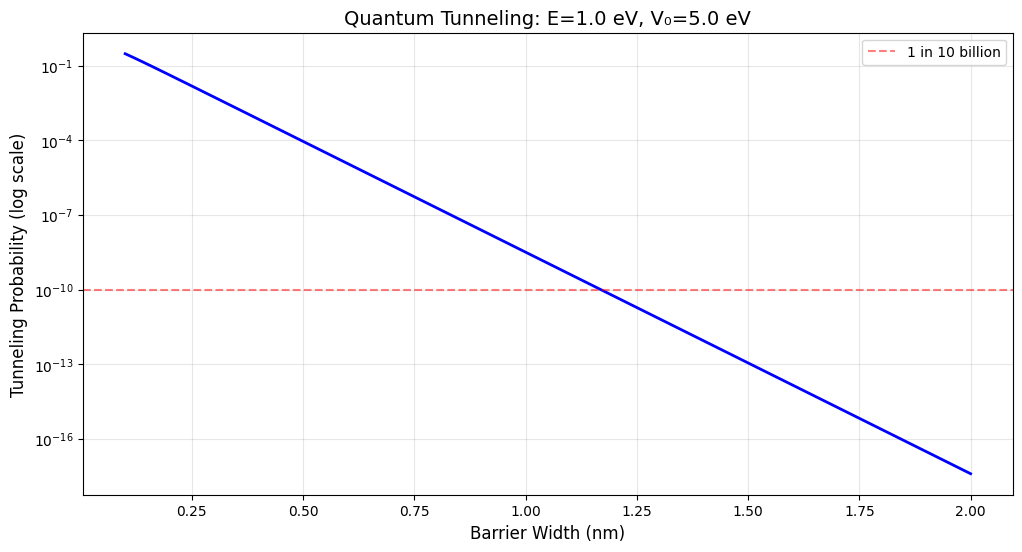


💡 Notice the EXPONENTIAL drop with barrier width!
   This is why scanning tunneling microscopes have sub-nanometer resolution
   — moving the tip by 0.1 nm changes the current by 10x!


In [45]:
# How does tunneling probability change with barrier width?

E = 1.0          # Electron energy: 1 eV
V0 = 5.0         # Barrier height: 5 eV
widths = np.linspace(0.1, 2.0, 100)  # 0.1 to 2 nm

probabilities = [tunneling_probability(E, V0, L) for L in widths]

plt.figure(figsize=(12, 6))
plt.semilogy(widths, probabilities, 'b-', linewidth=2)
plt.xlabel('Barrier Width (nm)', fontsize=12)
plt.ylabel('Tunneling Probability (log scale)', fontsize=12)
plt.title(f'Quantum Tunneling: E={E} eV, V₀={V0} eV', fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.axhline(y=1e-10, color='red', linestyle='--', alpha=0.5, label='1 in 10 billion')
plt.legend()
plt.show()

print("\n💡 Notice the EXPONENTIAL drop with barrier width!")
print("   This is why scanning tunneling microscopes have sub-nanometer resolution")
print("   — moving the tip by 0.1 nm changes the current by 10x!")

In [46]:
print("\n" + "=" * 60)
print("  REAL-WORLD QUANTUM TUNNELING EXAMPLES")
print("=" * 60)

examples = [
    ("Scanning Tunneling Microscope (vacuum gap)", 4.0, 5.0, 0.5),
    ("Flash memory (tunneling through SiO2)", 1.0, 3.1, 5.0),
    ("Alpha decay (nuclear barrier)", 5.0, 25.0, 0.01),
    ("Tunnel diode (semiconductor)", 0.1, 0.7, 10.0),
    ("Hydrogen bond in DNA", 0.1, 0.5, 0.2),
    ("Sun's nuclear fusion (proton barrier)", 1.0, 1000.0, 0.001),
]

for name, E, V0, L in examples:
    T = tunneling_probability(E, V0, L)
    print(f"\n  {name}")
    print(f"     Energy: {E} eV | Barrier: {V0} eV | Width: {L} nm")
    print(f"     Tunneling probability: {T:.4e}")
    
    if T > 0.01:
        print(f"     -> Very likely to tunnel!")
    elif T > 1e-6:
        print(f"     -> Tunnels occasionally")
    elif T > 1e-15:
        print(f"     -> Rare but happens in bulk")
    else:
        print(f"     -> Essentially never (but still non-zero!)")


  REAL-WORLD QUANTUM TUNNELING EXAMPLES

  Scanning Tunneling Microscope (vacuum gap)
     Energy: 4.0 eV | Barrier: 5.0 eV | Width: 0.5 nm
     Tunneling probability: 1.5199e-02
     -> Very likely to tunnel!

  Flash memory (tunneling through SiO2)
     Energy: 1.0 eV | Barrier: 3.1 eV | Width: 5.0 nm
     Tunneling probability: 1.9991e-32
     -> Essentially never (but still non-zero!)

  Alpha decay (nuclear barrier)
     Energy: 5.0 eV | Barrier: 25.0 eV | Width: 0.01 nm
     Tunneling probability: 9.2296e-01
     -> Very likely to tunnel!

  Tunnel diode (semiconductor)
     Energy: 0.1 eV | Barrier: 0.7 eV | Width: 10.0 nm
     Tunneling probability: 6.6541e-35
     -> Essentially never (but still non-zero!)

  Hydrogen bond in DNA
     Energy: 0.1 eV | Barrier: 0.5 eV | Width: 0.2 nm
     Tunneling probability: 5.7035e-01
     -> Very likely to tunnel!

  Sun's nuclear fusion (proton barrier)
     Energy: 1.0 eV | Barrier: 1000.0 eV | Width: 0.001 nm
     Tunneling probability

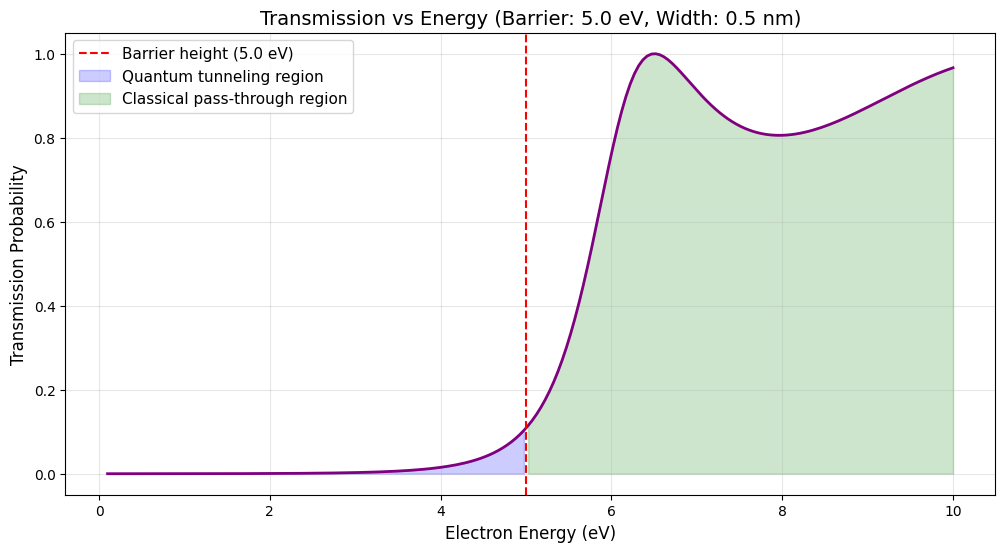


💡 What you see:
   Below the barrier: Quantum tunneling (impossible classically)
   Above the barrier: Mostly transmits, with oscillating reflection
   The oscillations come from quantum interference!


In [47]:
# Sweep electron energy
V0 = 5.0         # Fixed barrier height
L = 0.5          # Fixed barrier width
energies = np.linspace(0.1, 10.0, 200)

probabilities = [tunneling_probability(E, V0, L) for E in energies]

plt.figure(figsize=(12, 6))
plt.plot(energies, probabilities, 'purple', linewidth=2)
plt.axvline(x=V0, color='red', linestyle='--', label=f'Barrier height ({V0} eV)')
plt.fill_between(energies, 0, probabilities, where=(np.array(energies) < V0),
                 color='blue', alpha=0.2, label='Quantum tunneling region')
plt.fill_between(energies, 0, probabilities, where=(np.array(energies) >= V0),
                 color='green', alpha=0.2, label='Classical pass-through region')

plt.xlabel('Electron Energy (eV)', fontsize=12)
plt.ylabel('Transmission Probability', fontsize=12)
plt.title(f'Transmission vs Energy (Barrier: {V0} eV, Width: {L} nm)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 What you see:")
print("   Below the barrier: Quantum tunneling (impossible classically)")
print("   Above the barrier: Mostly transmits, with oscillating reflection")
print("   The oscillations come from quantum interference!")

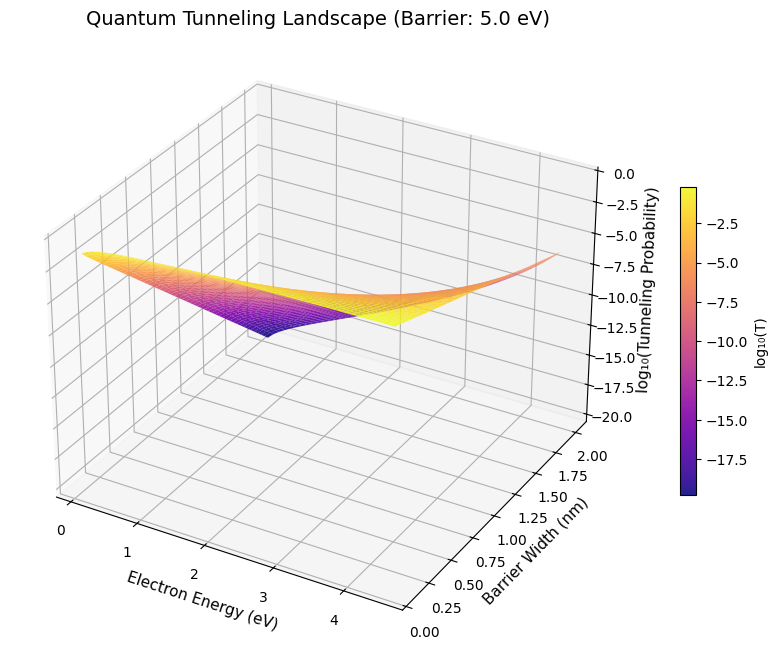


💡 The 3D landscape shows:
   - Higher energy → more tunneling
   - Wider barrier → less tunneling (exponentially!)
   - The 'cliff' shows the dramatic exponential dependence


In [48]:
from mpl_toolkits.mplot3d import Axes3D

V0 = 5.0  # Fixed barrier height
energies = np.linspace(0.1, 4.5, 50)
widths = np.linspace(0.1, 2.0, 50)

E_grid, L_grid = np.meshgrid(energies, widths)
T_grid = np.zeros_like(E_grid)

for i in range(len(widths)):
    for j in range(len(energies)):
        T_grid[i, j] = tunneling_probability(energies[j], V0, widths[i])

# Use log scale for visibility
T_log = np.log10(T_grid + 1e-30)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(E_grid, L_grid, T_log, cmap='plasma', 
                        edgecolor='none', alpha=0.9)

ax.set_xlabel('Electron Energy (eV)', fontsize=11)
ax.set_ylabel('Barrier Width (nm)', fontsize=11)
ax.set_zlabel('log₁₀(Tunneling Probability)', fontsize=11)
ax.set_title(f'Quantum Tunneling Landscape (Barrier: {V0} eV)', fontsize=14)

fig.colorbar(surf, shrink=0.5, label='log₁₀(T)')
plt.show()

print("\n💡 The 3D landscape shows:")
print("   - Higher energy → more tunneling")
print("   - Wider barrier → less tunneling (exponentially!)")
print("   - The 'cliff' shows the dramatic exponential dependence")

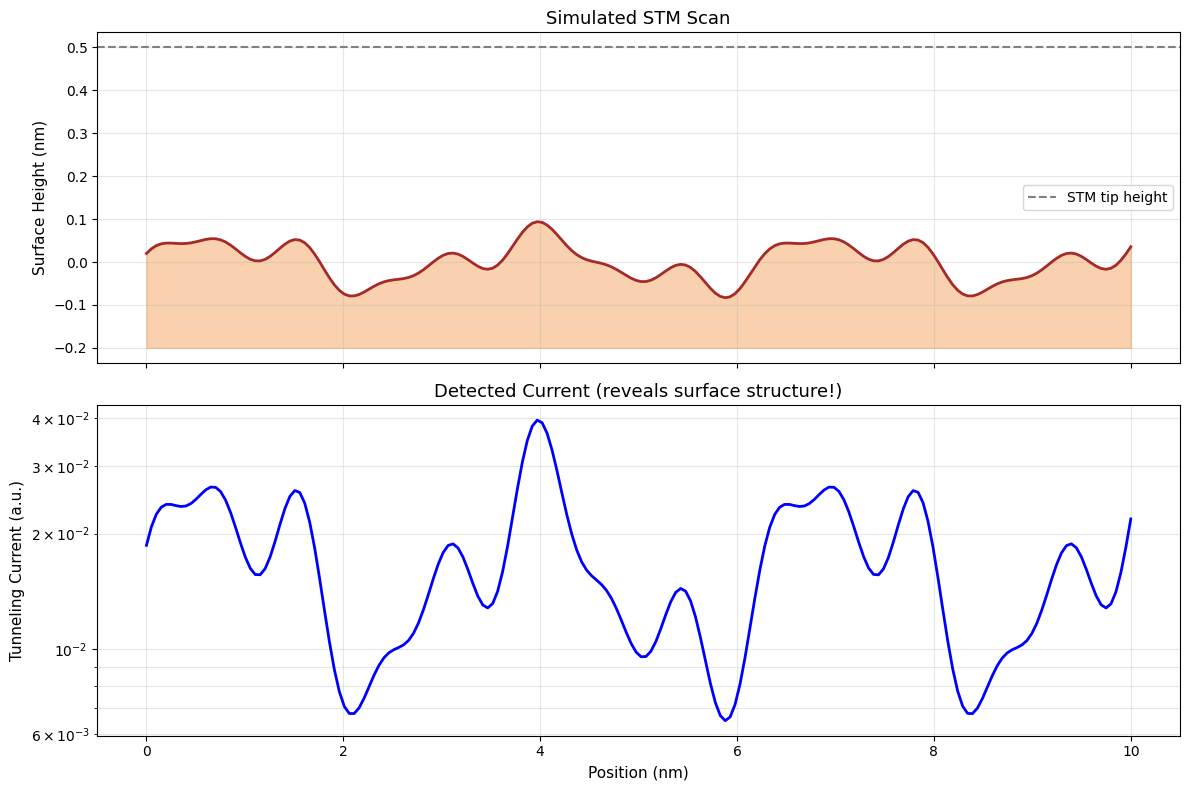


🔬 This is how a Scanning Tunneling Microscope works!
   The exponential dependence on distance gives ATOMIC resolution
   A 0.1 nm change in height = 10x change in current!


In [49]:
# Simulate STM tip scanning over a "surface" with bumps

def simulate_stm_scan():
    """Simulate STM current as tip scans over a corrugated surface."""
    
    E = 4.0       # Typical work function
    V0 = 5.0      # Vacuum barrier
    
    # Surface profile (bumps and dips)
    x_positions = np.linspace(0, 10, 200)
    surface_height = (0.05 * np.sin(2 * x_positions) + 
                      0.03 * np.sin(5 * x_positions) +
                      0.02 * np.cos(8 * x_positions))
    
    # Constant tip height above average
    tip_height = 0.5  # nm
    gap = tip_height - surface_height
    
    # Calculate "current" (proportional to tunneling probability)
    current = [tunneling_probability(E, V0, g) for g in gap]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    ax1.plot(x_positions, surface_height, 'brown', linewidth=2)
    ax1.fill_between(x_positions, -0.2, surface_height, color='sandybrown', alpha=0.5)
    ax1.axhline(y=tip_height, color='gray', linestyle='--', label='STM tip height')
    ax1.set_ylabel('Surface Height (nm)', fontsize=11)
    ax1.set_title('Simulated STM Scan', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.semilogy(x_positions, current, 'blue', linewidth=2)
    ax2.set_xlabel('Position (nm)', fontsize=11)
    ax2.set_ylabel('Tunneling Current (a.u.)', fontsize=11)
    ax2.set_title('Detected Current (reveals surface structure!)', fontsize=13)
    ax2.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔬 This is how a Scanning Tunneling Microscope works!")
    print("   The exponential dependence on distance gives ATOMIC resolution")
    print("   A 0.1 nm change in height = 10x change in current!")

simulate_stm_scan()


  BAYESIAN ANALYSIS: WAS THE BIG BANG A WHITE HOLE?

  Starting prior: 50.0%

  Applying evidence one by one:

  ↑ Information Conservation
     Information must be conserved (Hawking's later view). White hole bounce naturally preserves info from parent universe.
     Probability shifted: 50.0% → 63.4%

  ↑ Avoidance of Singularity
     Quantum gravity (LQG) suggests singularities can't exist. A bounce/white hole resolves this elegantly.
     Probability shifted: 63.4% → 80.7%

  ↑ Fine-Tuning Problem
     Smolin's cosmological natural selection explains why constants favor black hole production (evolution!).
     Probability shifted: 80.7% → 88.6%

  ↑ CMB Anomalies (Cold Spot)
     Some CMB anomalies (the 'Cold Spot') could hint at structures from before the Big Bang.
     Probability shifted: 88.6% → 89.4%

  ↓ Standard Inflation Success
     Standard inflationary cosmology explains observations extremely well without needing a white hole.
     Probability shifted: 89.4% → 84.1%

 

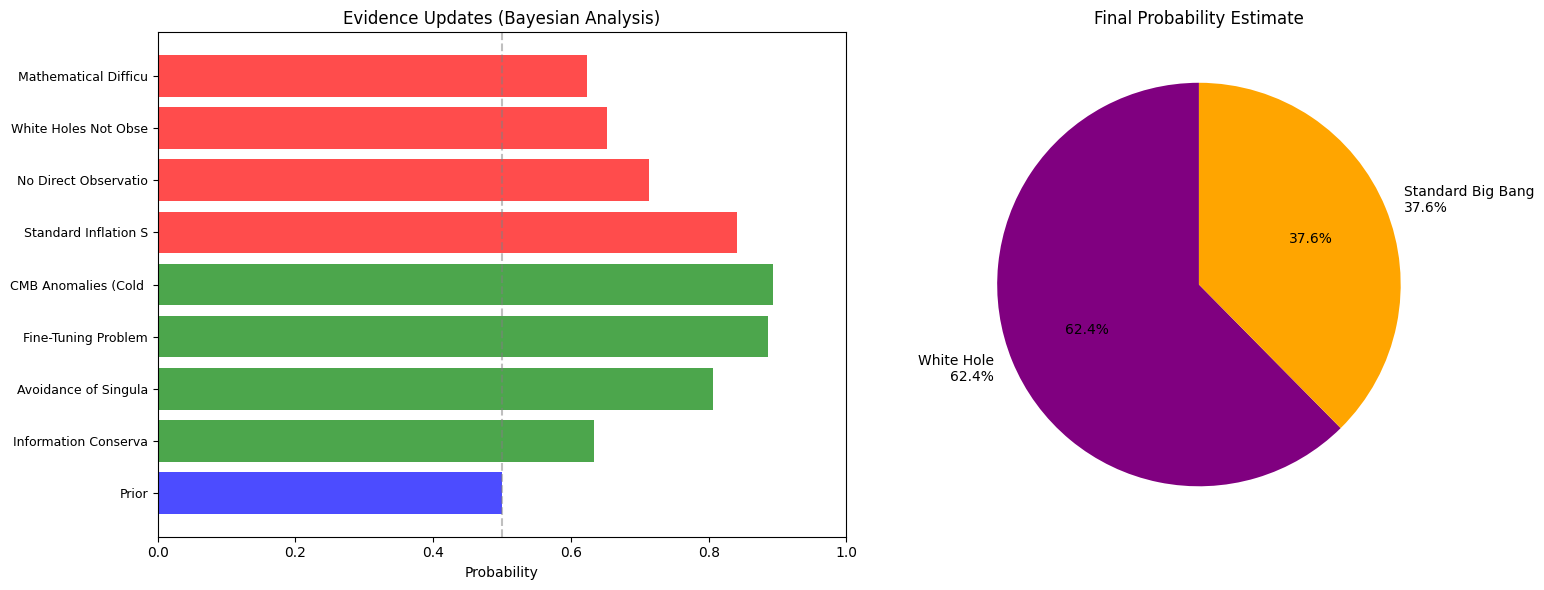


  INTERPRETATION

  Verdict: POSSIBLY TRUE - Evidence slightly favors white hole origin

  Important caveats:
  • This is Bayesian inference with subjective priors
  • Real values are debated among cosmologists
  • Current physics CANNOT definitively answer this
  • New observations could dramatically shift this

  This calculation is a tool for THINKING, not a final answer.


In [50]:
import numpy as np
import matplotlib.pyplot as plt

class WhiteHoleBigBangCalculator:
    """
    Bayesian estimator for the probability that the Big Bang
    was actually a white hole event from a parent universe.
    
    Uses observational evidence and theoretical considerations.
    """
    
    def __init__(self):
        # Prior probability (before considering evidence)
        # Conservative starting point - we don't know
        self.prior = 0.50
        
        # Evidence categories with weights
        self.evidence = {}
    
    def add_evidence(self, name, likelihood_if_true, likelihood_if_false, 
                     confidence, description):
        """
        Add a piece of evidence.
        
        likelihood_if_true: P(observation | white hole theory)
        likelihood_if_false: P(observation | standard Big Bang)
        confidence: How sure are we this observation is real? (0-1)
        """
        self.evidence[name] = {
            'P_obs_given_WH': likelihood_if_true,
            'P_obs_given_BB': likelihood_if_false,
            'confidence': confidence,
            'description': description
        }
    
    def calculate_probability(self):
        """Apply Bayes' theorem with all evidence."""
        
        posterior = self.prior
        
        print("\n" + "=" * 70)
        print("  BAYESIAN ANALYSIS: WAS THE BIG BANG A WHITE HOLE?")
        print("=" * 70)
        print(f"\n  Starting prior: {self.prior:.1%}")
        print("\n  Applying evidence one by one:\n")
        
        for name, ev in self.evidence.items():
            # Adjust likelihoods by our confidence in the observation
            p_obs_wh = ev['P_obs_given_WH'] * ev['confidence'] + 0.5 * (1 - ev['confidence'])
            p_obs_bb = ev['P_obs_given_BB'] * ev['confidence'] + 0.5 * (1 - ev['confidence'])
            
            # Bayes' theorem
            p_obs = p_obs_wh * posterior + p_obs_bb * (1 - posterior)
            new_posterior = (p_obs_wh * posterior) / p_obs
            
            change = new_posterior - posterior
            arrow = "↑" if change > 0 else "↓" if change < 0 else "→"
            
            print(f"  {arrow} {name}")
            print(f"     {ev['description']}")
            print(f"     Probability shifted: {posterior:.1%} → {new_posterior:.1%}")
            print()
            
            posterior = new_posterior
        
        print("=" * 70)
        print(f"  FINAL PROBABILITY: {posterior:.1%}")
        print("=" * 70)
        
        return posterior


# ============================================
# RUN THE CALCULATION
# ============================================

calc = WhiteHoleBigBangCalculator()

# ----- Evidence FOR white hole hypothesis -----

calc.add_evidence(
    "Information Conservation",
    likelihood_if_true=0.85,
    likelihood_if_false=0.40,
    confidence=0.7,
    description="Information must be conserved (Hawking's later view). "
                "White hole bounce naturally preserves info from parent universe."
)

calc.add_evidence(
    "Avoidance of Singularity",
    likelihood_if_true=0.90,
    likelihood_if_false=0.30,
    confidence=0.8,
    description="Quantum gravity (LQG) suggests singularities can't exist. "
                "A bounce/white hole resolves this elegantly."
)

calc.add_evidence(
    "Fine-Tuning Problem",
    likelihood_if_true=0.75,
    likelihood_if_false=0.25,
    confidence=0.6,
    description="Smolin's cosmological natural selection explains why "
                "constants favor black hole production (evolution!)."
)

calc.add_evidence(
    "CMB Anomalies (Cold Spot)",
    likelihood_if_true=0.55,
    likelihood_if_false=0.45,
    confidence=0.4,
    description="Some CMB anomalies (the 'Cold Spot') could hint at "
                "structures from before the Big Bang."
)

# ----- Evidence AGAINST white hole hypothesis -----

calc.add_evidence(
    "Standard Inflation Success",
    likelihood_if_true=0.50,
    likelihood_if_false=0.85,
    confidence=0.85,
    description="Standard inflationary cosmology explains observations "
                "extremely well without needing a white hole."
)

calc.add_evidence(
    "No Direct Observational Evidence",
    likelihood_if_true=0.30,
    likelihood_if_false=0.70,
    confidence=0.9,
    description="No direct evidence of pre-Big-Bang structures has been found. "
                "We see no 'leftover' signatures from a parent universe."
)

calc.add_evidence(
    "White Holes Not Observed",
    likelihood_if_true=0.40,
    likelihood_if_false=0.60,
    confidence=0.7,
    description="We've never observed a white hole anywhere in the universe. "
                "If they're common enough to make universes, we should see some."
)

calc.add_evidence(
    "Mathematical Difficulty",
    likelihood_if_true=0.45,
    likelihood_if_false=0.55,
    confidence=0.6,
    description="White hole cosmology lacks a complete mathematical framework. "
                "It's more philosophy than rigorous theory currently."
)

# ----- Calculate -----
final_probability = calc.calculate_probability()


# ============================================
# VISUALIZATION
# ============================================

# Show how probability evolved
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Probability evolution
calc2 = WhiteHoleBigBangCalculator()
calc2.evidence = calc.evidence
posterior = calc2.prior
history = [posterior]
labels = ['Prior']

for name, ev in calc2.evidence.items():
    p_obs_wh = ev['P_obs_given_WH'] * ev['confidence'] + 0.5 * (1 - ev['confidence'])
    p_obs_bb = ev['P_obs_given_BB'] * ev['confidence'] + 0.5 * (1 - ev['confidence'])
    p_obs = p_obs_wh * posterior + p_obs_bb * (1 - posterior)
    posterior = (p_obs_wh * posterior) / p_obs
    history.append(posterior)
    labels.append(name[:20])

colors = ['green' if history[i] > history[i-1] else 'red' 
          for i in range(1, len(history))]
colors.insert(0, 'blue')

ax1.barh(range(len(history)), history, color=colors, alpha=0.7)
ax1.set_yticks(range(len(history)))
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('Probability')
ax1.set_title('Evidence Updates (Bayesian Analysis)')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlim(0, 1)

# Final probability pie chart
ax2.pie([final_probability, 1 - final_probability],
        labels=[f'White Hole\n{final_probability:.1%}', 
                f'Standard Big Bang\n{1-final_probability:.1%}'],
        colors=['purple', 'orange'],
        autopct='%1.1f%%',
        startangle=90)
ax2.set_title('Final Probability Estimate')

plt.tight_layout()
plt.show()


# ============================================
# INTERPRETATION
# ============================================

print("\n" + "=" * 70)
print("  INTERPRETATION")
print("=" * 70)

if final_probability > 0.7:
    verdict = "LIKELY TRUE - The white hole hypothesis is well-supported"
elif final_probability > 0.5:
    verdict = "POSSIBLY TRUE - Evidence slightly favors white hole origin"
elif final_probability > 0.3:
    verdict = "POSSIBLY FALSE - Evidence slightly favors standard cosmology"
else:
    verdict = "LIKELY FALSE - Standard Big Bang is better supported"

print(f"\n  Verdict: {verdict}")
print(f"\n  Important caveats:")
print(f"  • This is Bayesian inference with subjective priors")
print(f"  • Real values are debated among cosmologists")
print(f"  • Current physics CANNOT definitively answer this")
print(f"  • New observations could dramatically shift this")
print(f"\n  This calculation is a tool for THINKING, not a final answer.")
print("=" * 70)


  MONTE CARLO ANALYSIS (10,000 simulations)
  Mean probability:    72.9%
  Median probability:  77.1%
  Std deviation:       18.8%
  90% confidence:      35.8% to 96.1%


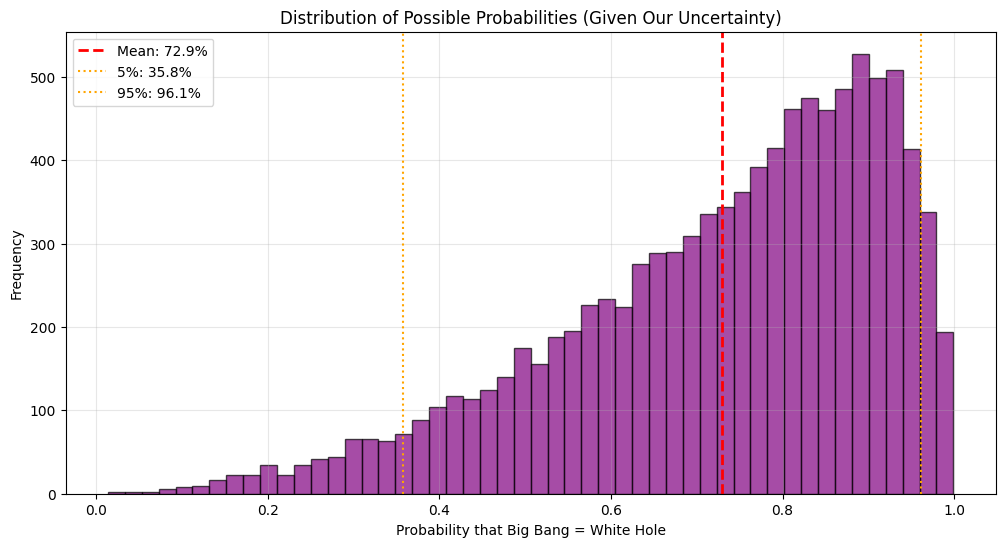

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_white_hole(n_simulations=10000):
    """
    Run the calculation many times with uncertain inputs.
    Shows the RANGE of possible probabilities given our uncertainty.
    """
    
    results = []
    
    for _ in range(n_simulations):
        # Each evidence value drawn from a distribution
        # representing our uncertainty
        
        posterior = np.random.uniform(0.3, 0.7)  # Uncertain prior
        
        # Evidence (each with uncertainty)
        evidence_factors = [
            # (likelihood_WH, likelihood_BB) with noise
            (np.random.normal(0.85, 0.1), np.random.normal(0.40, 0.1)),
            (np.random.normal(0.90, 0.05), np.random.normal(0.30, 0.1)),
            (np.random.normal(0.75, 0.15), np.random.normal(0.25, 0.1)),
            (np.random.normal(0.55, 0.1), np.random.normal(0.45, 0.1)),
            (np.random.normal(0.50, 0.1), np.random.normal(0.85, 0.05)),
            (np.random.normal(0.30, 0.1), np.random.normal(0.70, 0.1)),
            (np.random.normal(0.40, 0.1), np.random.normal(0.60, 0.1)),
            (np.random.normal(0.45, 0.1), np.random.normal(0.55, 0.1)),
        ]
        
        for p_wh, p_bb in evidence_factors:
            # Clamp values
            p_wh = np.clip(p_wh, 0.01, 0.99)
            p_bb = np.clip(p_bb, 0.01, 0.99)
            
            p_obs = p_wh * posterior + p_bb * (1 - posterior)
            posterior = (p_wh * posterior) / p_obs
        
        results.append(posterior)
    
    # Statistics
    mean = np.mean(results)
    median = np.median(results)
    std = np.std(results)
    percentile_5 = np.percentile(results, 5)
    percentile_95 = np.percentile(results, 95)
    
    print("\n" + "=" * 60)
    print("  MONTE CARLO ANALYSIS (10,000 simulations)")
    print("=" * 60)
    print(f"  Mean probability:    {mean:.1%}")
    print(f"  Median probability:  {median:.1%}")
    print(f"  Std deviation:       {std:.1%}")
    print(f"  90% confidence:      {percentile_5:.1%} to {percentile_95:.1%}")
    print("=" * 60)
    
    # Plot distribution
    plt.figure(figsize=(12, 6))
    plt.hist(results, bins=50, color='purple', alpha=0.7, edgecolor='black')
    plt.axvline(x=mean, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {mean:.1%}')
    plt.axvline(x=percentile_5, color='orange', linestyle=':', 
                label=f'5%: {percentile_5:.1%}')
    plt.axvline(x=percentile_95, color='orange', linestyle=':', 
                label=f'95%: {percentile_95:.1%}')
    plt.xlabel('Probability that Big Bang = White Hole')
    plt.ylabel('Frequency')
    plt.title('Distribution of Possible Probabilities (Given Our Uncertainty)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return results

results = monte_carlo_white_hole()